In [1]:
import pandas as pd

In [2]:
compas_initial = pd.read_csv ('/home/jsaray/Data Science/Fairness/compas_without_duplicates.csv') 

In [3]:
compas_filtered_columns = compas_initial.drop(['AssessmentType','Screening_Date','AssessmentID','Case_ID','Person_ID','LastName','FirstName','MiddleName','ScaleSet_ID','ScaleSet','AssessmentReason','RecSupervisionLevel','IsCompleted','IsDeleted'],axis=1)	

In [4]:
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
def reduce_to2(x):
    if x != 'Caucasian':
        return 'No Caucasian'
    else:
        return x
compas_filtered_columns['C_Agency_Text'] = le.fit_transform( compas_filtered_columns['Agency_Text'] )
compas_filtered_columns['C_Sex_Code_Text'] = le.fit_transform( compas_filtered_columns['Sex_Code_Text'] )
compas_filtered_columns['C_Ethnic_Code_Text'] = compas_filtered_columns['Ethnic_Code_Text'].apply(lambda x : reduce_to2(x))
compas_filtered_columns['C_LegalStatus'] = le.fit_transform( compas_filtered_columns['LegalStatus'] )
compas_filtered_columns['C_Language'] = le.fit_transform( compas_filtered_columns['Language'] )
compas_filtered_columns['C_CustodyStatus'] = le.fit_transform( compas_filtered_columns['CustodyStatus'] )
compas_filtered_columns['C_MaritalStatus'] = le.fit_transform( compas_filtered_columns['MaritalStatus'] )
compas_filtered_columns['C_RecSupervisionLevelText'] = le.fit_transform( compas_filtered_columns['RecSupervisionLevelText'] )
compas_filtered_columns['C_DisplayText'] = le.fit_transform( compas_filtered_columns['DisplayText'] )
compas_filtered_columns['C_ScoreText'] = le.fit_transform( compas_filtered_columns['ScoreText'] )
compas_filtered_columns['YearOfBirth'] = compas_filtered_columns['DateOfBirth'].apply(lambda x : x.split('/')[-1])

In [5]:
compas_to_analysis = compas_filtered_columns.drop(['Agency_Text', 'Sex_Code_Text' ,'Ethnic_Code_Text','LegalStatus', 'Language','CustodyStatus' ,'MaritalStatus' ,'RecSupervisionLevelText' ,'DisplayText', 'ScoreText','DateOfBirth'],axis=1)

In [6]:
attr_sim_compas = {
    'C_Agency_Text': 'cat',
    'C_Sex_Code_Text': 'cat',
    'C_LegalStatus': 'cat',
    'C_Language': 'cat',
    'C_CustodyStatus': 'cat',
    'C_MaritalStatus': 'cat',
    'C_RecSupervisionLevelText': 'cat',
    'C_DisplayText': 'cat',
    'Scale_ID': 'num',
    'RawScore': 'num',
    'DecileScore': 'num',
    'YearOfBirth': 'num',
    'C_ScoreText': 'target',
}

In [7]:
compas_to_analysis['YearOfBirth'] = compas_to_analysis['YearOfBirth'].astype('int64')

In [8]:
compas_to_analysis.shape

(18610, 15)

In [9]:
from kafkanator.dataviz import simmilar_subjects_treatment_plot

Analyzing row  0
Analyzing row  100
Analyzing row  200
Analyzing row  300
Analyzing row  400
x data  [106, 114, 106, 0, 370, 150, 421, 437, 470, 150]  y data  [269, 344, 21, 411, 135, 236, 175, 252, 286, 445] z data  [1.08, 1.09, 1.1, 1.11, 1.1199999999999999, 1.14, 1.15, 1.1600000000000001, 1.1600000000000001, 1.18]


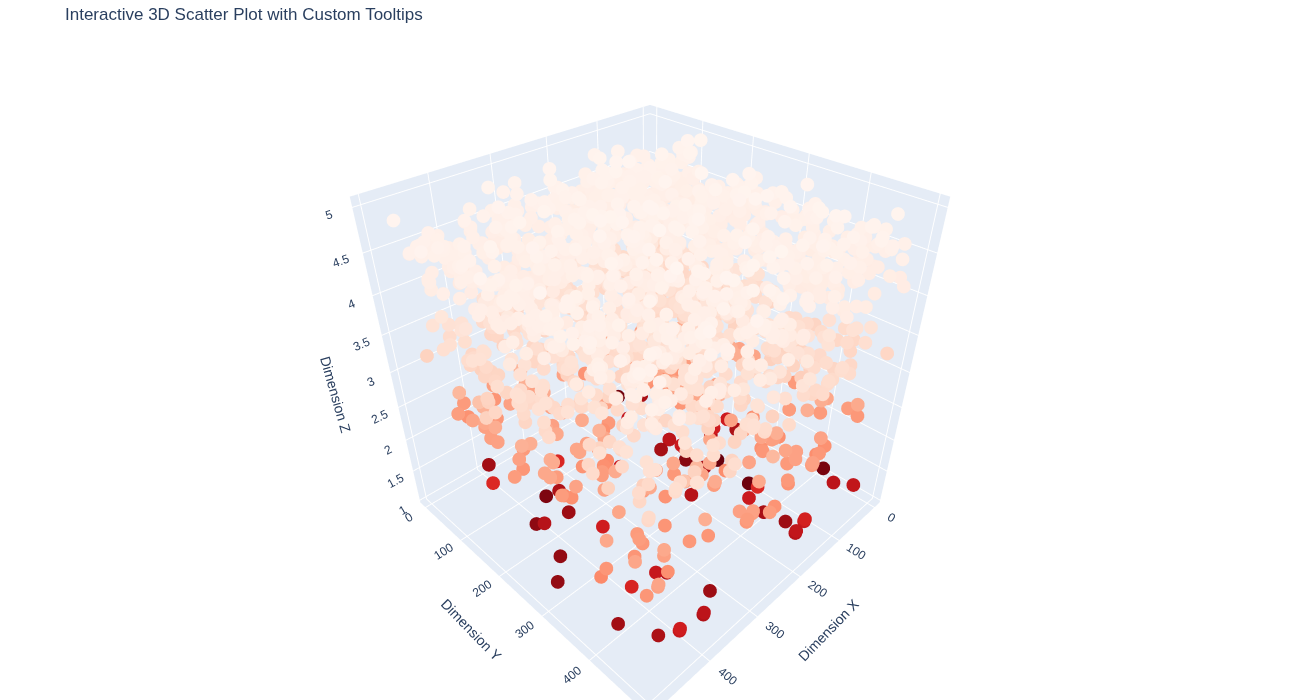

In [10]:
simmilar_subjects_treatment_plot( compas_to_analysis , 'C_Ethnic_Code_Text' ,['Caucasian','No Caucasian'] ,  500 , attr_sim_compas  )